In [153]:
import numpy as np
from numpy import where
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
warnings.filterwarnings('ignore')
import matplotlib.ticker as mtick
import matplotlib.gridspec as grid_spec
from matplotlib.offsetbox import AnchoredText
from mpl_toolkits.axes_grid1 import make_axes_locatable


# Data pre-processing 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Modelling 
from sklearn.metrics import (
    roc_auc_score,
    precision_score, 
    accuracy_score, 
    recall_score,
)


from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    GradientBoostingClassifier)



from feature_engine import encoding as ce


from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score, cross_validate, RepeatedStratifiedKFold



from sklearn.pipeline import Pipeline

from imblearn.over_sampling import ADASYN, SMOTE

from imblearn.pipeline import make_pipeline
from imblearn.pipeline import Pipeline as imbPipeline


import optuna

import numpy as np 
import pandas as pd

In [154]:
df=pd.read_csv('train_apps.csv',sep=',')
print(df.shape)

(145241, 28)


In [155]:
df.describe()

,front_id,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,cnt_deb_loan_90,...,loan_rev_min_start_fin,app_term_mean_360,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,target_value
count,145241.000000,145241.000000,145241.000000,145241.000000,145241.000000,145241.000000,94053.000000,91130.000000,83788.000000,113783.000000,...,20535.000000,89358.000000,5509.000000,66768.000000,120873.000000,94053.000000,94053.000000,94053.000000,16544.000000,145241.000000
mean,194949.148987,0.007895,-0.079469,-0.152180,0.451652,0.236037,0.551323,-0.115486,-0.571310,1.541818,...,0.044604,-0.504407,2.420419,0.270523,-0.216002,-0.271407,-0.411166,-0.018910,-0.094382,0.060906
std,53666.269041,1.566315,2.859922,2.272220,17.085141,0.806974,0.682818,0.598802,3.388152,2.191769,...,1.096088,1.564486,5.066634,2.024606,1.892380,1.567742,2.388636,0.618172,1.270767,0.239158
min,100001.000000,-5.616959,-8.378948,-6.738516,-161.117698,-0.400695,0.000000,-3.609463,-20.210398,0.000000,...,-1.737297,-5.301281,0.000000,-2.477073,-4.700790,-3.081808,-9.486675,-0.799661,-6.316172,0.000000
25%,148265.000000,-1.117611,-2.560781,-2.121539,-2.129309,-0.400695,0.000000,-0.452219,-2.571386,0.000000,...,-0.756893,-1.178062,0.000000,-1.363754,-1.351879,-0.903621,-1.943585,-0.659359,-0.948789,0.000000
50%,198286.000000,0.000000,-0.379964,-0.366457,-0.177442,-0.400695,0.000000,-0.027592,-0.141262,0.000000,...,-0.030479,0.000000,0.000000,-0.150013,0.000000,0.005186,-0.108141,-0.009033,-0.065987,0.000000
75%,240992.000000,0.961691,2.368351,1.828130,1.774424,0.801389,1.196210,0.318007,1.871279,2.999207,...,0.464803,0.000000,1.869090,1.408386,1.091873,0.869320,1.345503,0.475330,0.817189,0.000000
max,281552.000000,3.030871,6.131498,4.708039,165.021431,1.602779,2.678288,1.775716,10.830259,14.587305,...,7.622264,12.369656,14.952721,7.821749,7.419594,4.304125,7.469825,3.023513,3.823178,1.000000


In [156]:
df[df['front_id'].duplicated()]

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value


In [157]:
df.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'app_term_mean_360','overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','sum_deb_investment_90'],axis=1,inplace=True)

In [158]:
df

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,cnt_deb_ul_ip_90,balance_rur_amt_30_min,cnt_cred_loan_90,fl_hdb_bki_total_active_products,count_all_corp_dashboard_events,db_group_last,fl_adminarea,target_value
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,-5.561599,NaN,NaN,NaN,lombard,NaN,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,-4.466656,1.466815,0.000000,NaN,-3.400318,inn_scoring,NaN,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,5.291707,4.041974,0.000000,NaN,3.015012,NaN,NaN,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,-3.322507,NaN,NaN,NaN,NaN,NaN,0
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,-1.373655,4.324315,6.729738,NaN,1.506380,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,2.599715,-5.527199,0.000000,1.302069,1.589065,zalog_light,Новосибирская область,0
145237,0.845440,3.639458,3.605443,1.596982,1.602779,-1.037194,3.052725,0.000000,-4.700790,0.665258,inn_scoring,г. Москва,0
145238,1.690880,3.960429,2.995393,3.903733,1.602779,2.863267,-5.561599,8.491984,-1.351879,2.272156,inn_scoring,г. Санкт - Петербург,0
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0.238218,-5.561599,16.983968,1.674455,-0.305594,inn_scoring,Красноярский край,0


In [159]:
[var for var in df.columns if df[var].isnull().mean()>0]

['cnt_deb_ul_ip_90',
 'balance_rur_amt_30_min',
 'cnt_cred_loan_90',
 'fl_hdb_bki_total_active_products',
 'count_all_corp_dashboard_events',
 'db_group_last',
 'fl_adminarea']

In [160]:
df.isnull().sum()

loan_amount_last                        0
overdraft_limit_min                     0
overdraft_limit_max                     0
offered_rate                            0
cb_rate                                 0
cnt_deb_ul_ip_90                    30305
balance_rur_amt_30_min              34826
cnt_cred_loan_90                    31458
fl_hdb_bki_total_active_products    24368
count_all_corp_dashboard_events     51188
db_group_last                       55883
fl_adminarea                        43310
target_value                            0
dtype: int64

In [161]:
df_feature=df[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate','target_value']]

In [162]:
df_feature

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,target_value
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,0
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,0
...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,0
145237,0.845440,3.639458,3.605443,1.596982,1.602779,0
145238,1.690880,3.960429,2.995393,3.903733,1.602779,0
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0


In [163]:
[var for var in df_feature.columns if df_feature[var].isnull().mean()>0]

[]

In [164]:
num_vars = [var for var in df_feature.columns
           if df_feature[var].dtype != 'O' and var!='target_value']
print('The number of numerical variables: {}'.format(len(num_vars)))

The number of numerical variables: 5


In [165]:
df_feature['target_value'].value_counts()/len(df_feature)

target_value
0    0.939094
1    0.060906
Name: count, dtype: float64

In [166]:
df_feature.nunique()

loan_amount_last       3205
overdraft_limit_min    2052
overdraft_limit_max    2056
offered_rate            134
cb_rate                   4
target_value              2
dtype: int64

In [167]:
continous = []
discrete = []
for num in num_vars:
    if df_feature[num].nunique() < 10:
        discrete.append(num)
    else: 
        continous.append(num)
        
print('There are {} continous variables'.format(len(continous)))
print('The continous variables are: {}'.format(continous))
print('')
print('There are {} discrete variables'.format(len(discrete)))
print('The discrete variable is: {}'.format(discrete))

There are 4 continous variables
The continous variables are: ['loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max', 'offered_rate']

There are 1 discrete variables
The discrete variable is: ['cb_rate']


In [168]:
def plot_nums(df, variable):
    plt.figure(figsize=(16, 4))
    
    plt.subplot(1,3,1)
    df[variable].hist(bins=30)
    plt.title('Histogram')
    plt.xlabel(variable)
    
    plt.subplot(1,3,2)
    stats.probplot(df[variable], plot=plt)
    
    plt.subplot(1,3,3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')
    
    plt.show()

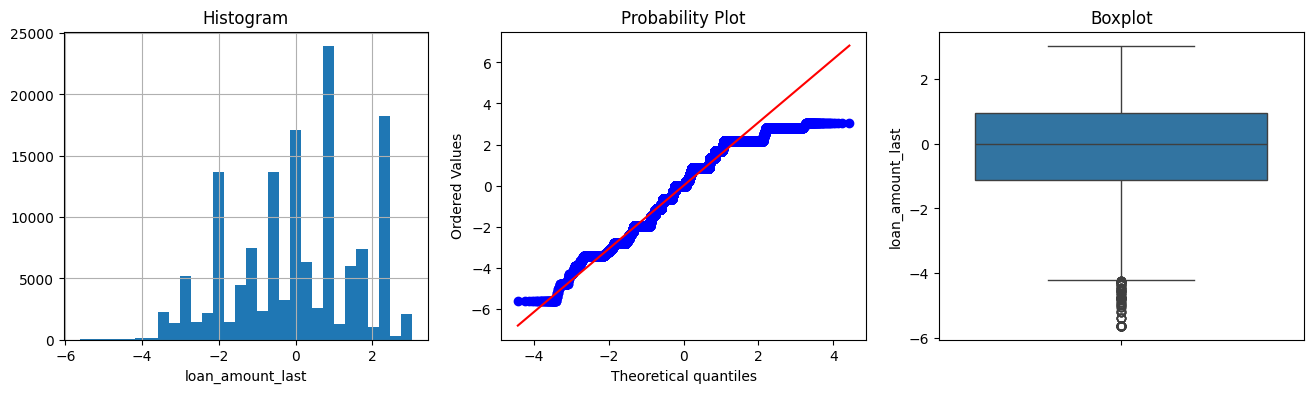

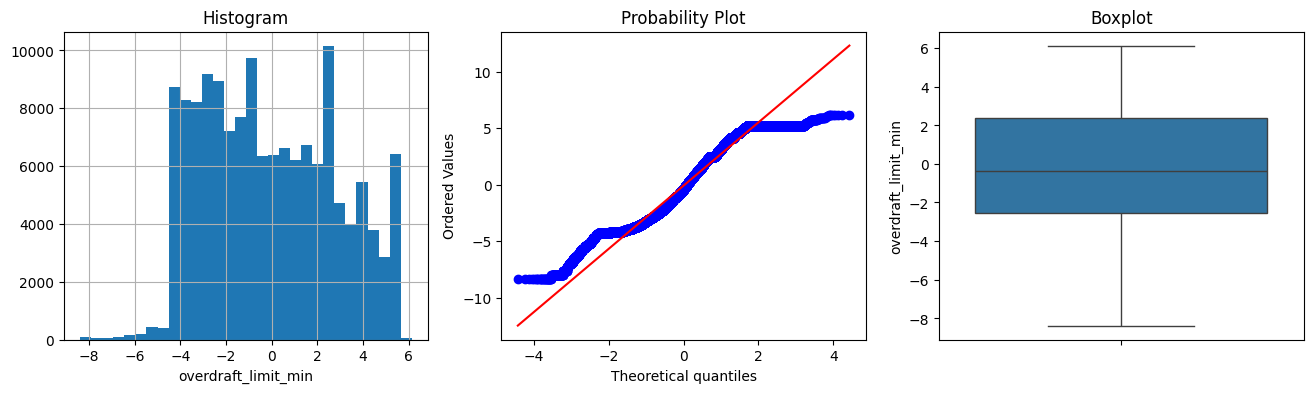

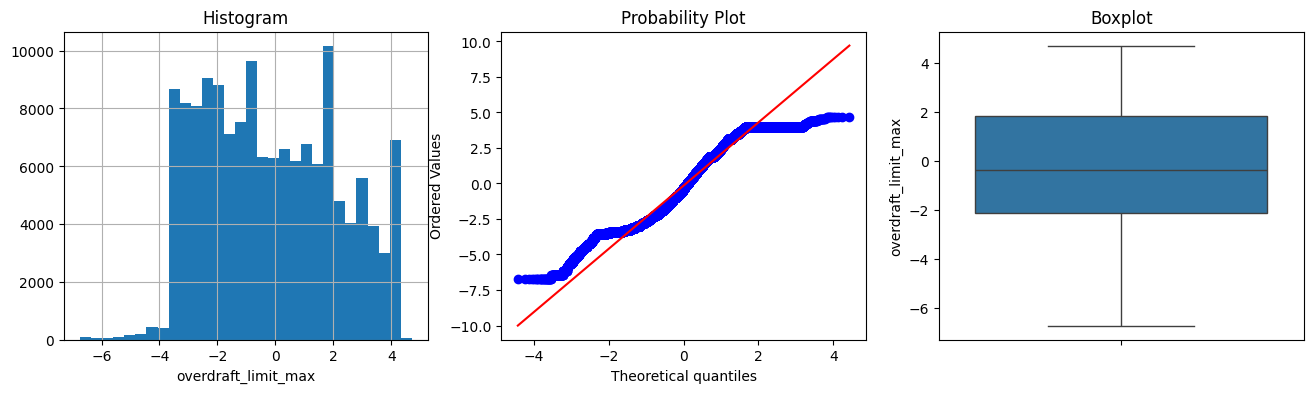

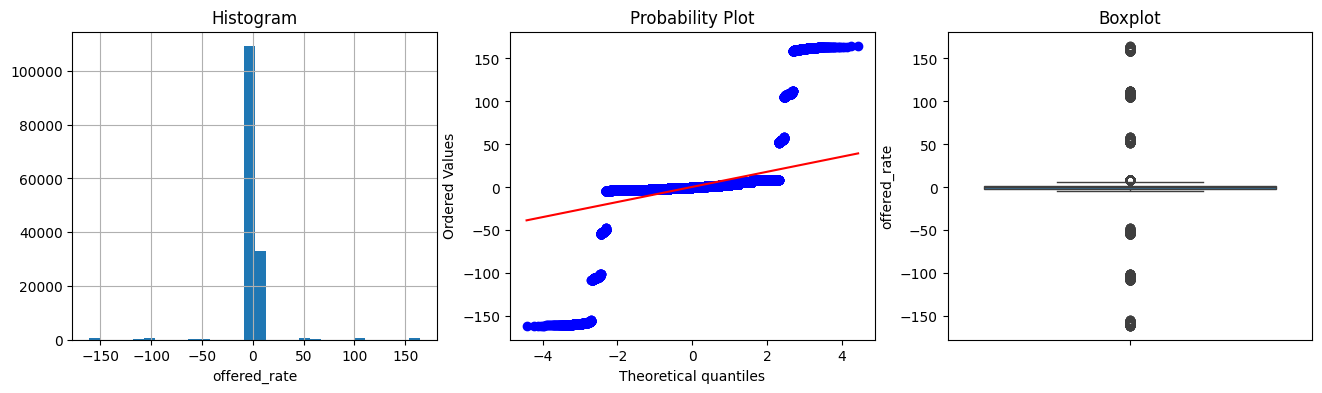

In [169]:
for var in continous:
    plot_nums(df_feature, var)

In [170]:
corr = df_feature.corr()

In [171]:

df_feature = df_feature.rename(columns={'target_value': 'Target'})

target_map = {0:'Not approved',
             1: 'approved'}

df_feature['Target'] = df_feature['Target'].map(target_map)

colors_blue = ["#132C33", "#264D58", '#17869E', '#51C4D3', '#B4DBE9']
colors_dark = ["#1F1F1F", "#313131", '#636363', '#AEAEAE', '#DADADA']
colors_green = ['#01411C','#4B6F44','#4F7942','#74C365','#D0F0C0']

In [172]:
Not_approved = df_feature[df_feature['Target']!='approved']
approved = df_feature[df_feature['Target']=='approved']

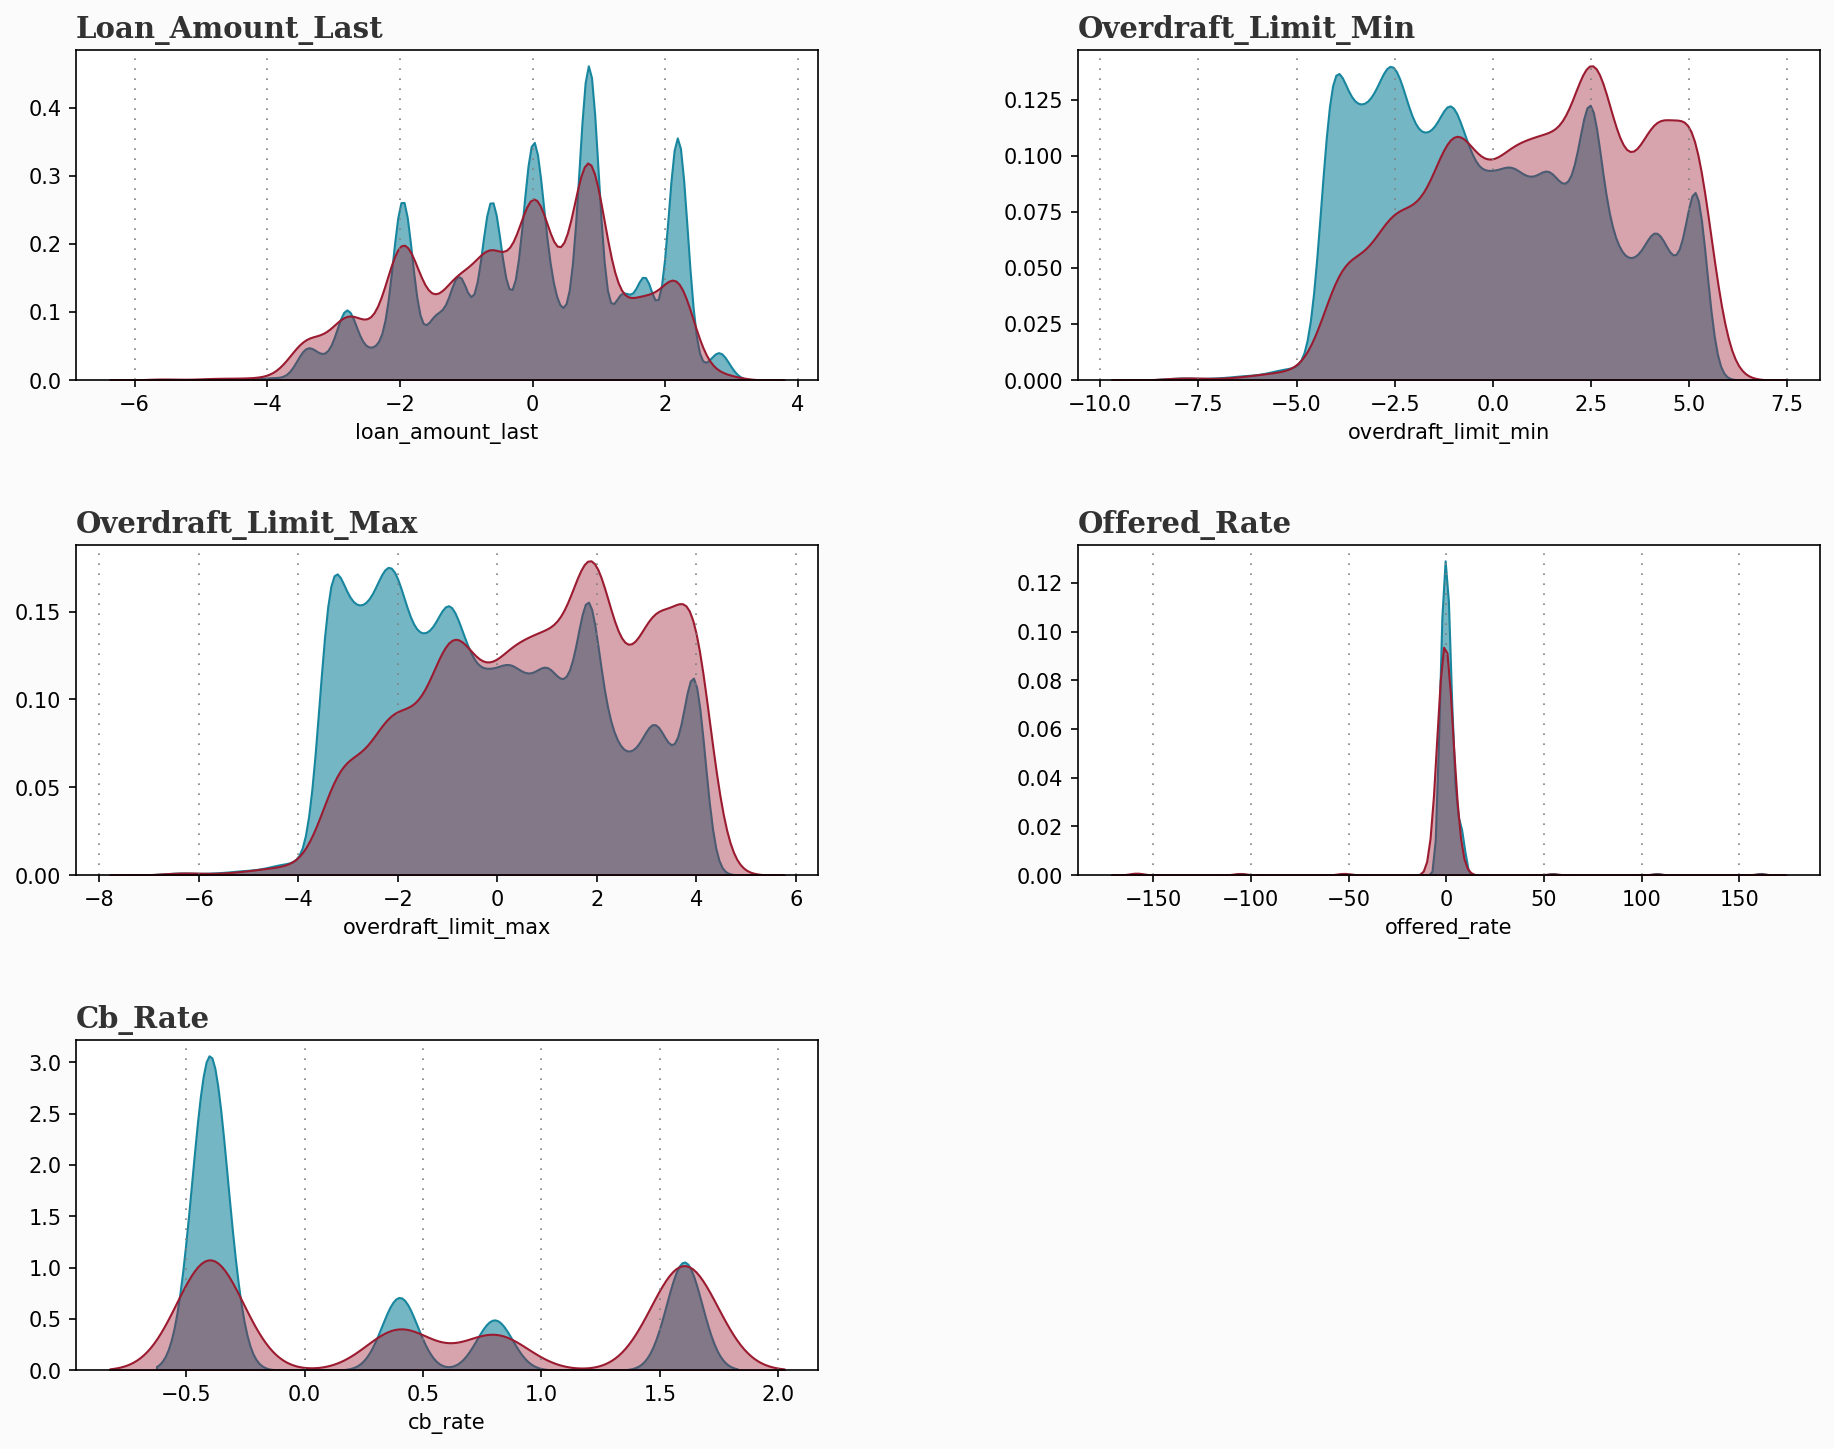

In [173]:
background_color = '#fbfbfb'

fig = plt.figure(figsize=(15,20), dpi=150)
fig.patch.set_facecolor(background_color) 
gs = fig.add_gridspec(5, 2)
gs.update(wspace=0.35, hspace=0.5)


axes = [fig.add_subplot(gs[0,0]),
        fig.add_subplot(gs[0,1]),
        fig.add_subplot(gs[1,0]),
        fig.add_subplot(gs[1,1]),
        fig.add_subplot(gs[2,0])]

num_feats = ['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate']

def HistPlots(df_feature, xVar, ax):
    

    sns.kdeplot(Not_approved[xVar], ax=ax, color=colors_blue[2], alpha=0.6, shade=True, label='Not_approved')
    sns.kdeplot(approved[xVar], ax=ax, color='#9b1b30', alpha=0.4, shade=True, label='approved')
    ax.grid(which='major', color='gray', linestyle=':', axis='x', zorder=0, dashes=(1,5))
    #ax.set(yticks=[])
    ax.set_title(f'{xVar}'.title(), fontsize=14, fontweight='bold', fontfamily='serif',
                color='#323232', loc='left')

    ax.set_ylabel('')

    

for ax, xVar in zip(axes, num_feats):
    HistPlots(df_feature, xVar, ax)
    







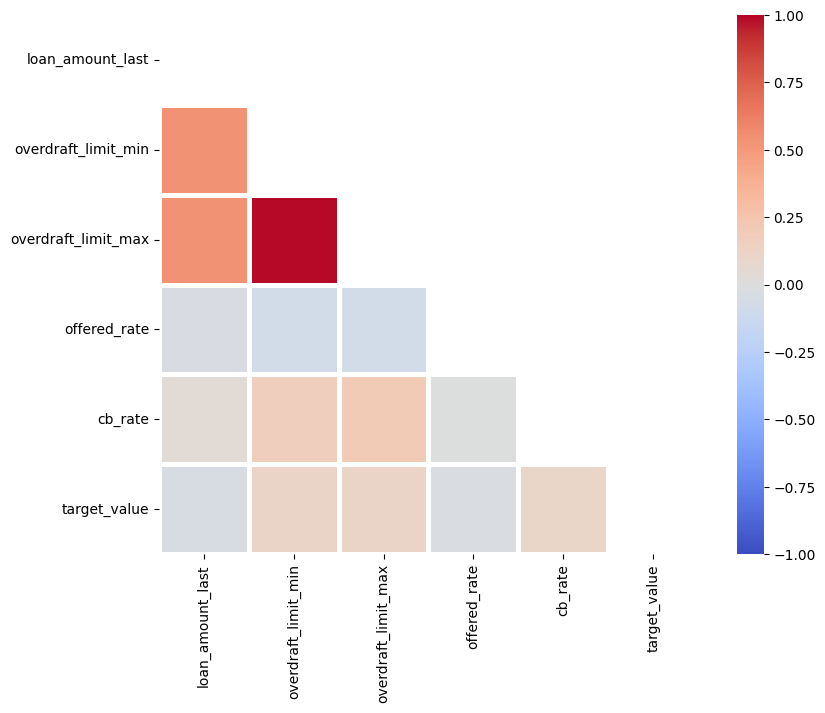

In [174]:

mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(10,7))

pl = sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1.0, vmin=-1.0, 
                center=0, square=True, linewidths=2.5)
plt.show()

In [175]:
df=pd.read_csv('train_apps.csv',sep=',')

In [176]:
df.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'app_term_mean_360','overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','sum_deb_investment_90'],axis=1,inplace=True)

In [177]:
df_feature=df[['loan_amount_last','overdraft_limit_min','overdraft_limit_max','offered_rate','cb_rate','target_value']]

In [178]:
df_feature

,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,target_value
0,1.339991,-1.847954,-1.586546,1.774424,-0.400695,0
1,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0
2,2.185431,3.167063,2.369547,-0.709770,-0.400695,0
3,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,0
4,0.845440,4.559196,3.467730,-2.484194,-0.400695,0
...,...,...,...,...,...,...
145236,1.339991,2.480726,1.828130,3.903733,1.602779,0
145237,0.845440,3.639458,3.605443,1.596982,1.602779,0
145238,1.690880,3.960429,2.995393,3.903733,1.602779,0
145239,0.845440,-2.742346,-2.292086,2.661636,1.602779,0


In [179]:
X_train, X_test, y_train, y_test = train_test_split(df_feature.drop(['target_value'], axis=1),df_feature['target_value'], test_size=0.2, random_state=0, 
)

X_train.shape, X_test.shape 

((116192, 5), (29049, 5))

In [180]:
best_param = {
    'n_estimators': 658,
    'criterion': 'friedman_mse',
    'max_depth': 5,
    'min_samples_split': 0.017209668061883378,
    'max_features': 'sqrt',
    'learning_rate': 0.050497537295197764
}

In [181]:
model_pipe = imbPipeline([
    
    ("scale", StandardScaler()),
    ("oversampling", ADASYN(sampling_strategy='auto', random_state=0, n_neighbors=5)),
    ("gbm", GradientBoostingClassifier(**best_param))
])

In [182]:
scoring = {'accuracy': 'accuracy',
           'recall': 'recall_macro',
           'precision': 'precision_macro',
           'roc-auc': 'roc_auc'}

In [184]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
scores = cross_validate(model_pipe, X_train, y_train, scoring=scoring)

In [185]:
scores

{'fit_time': array([109.38222694, 110.52829361, 114.58553481,  99.94221044,
        100.21732187]),
 'score_time': array([0.87089753, 0.68132877, 0.71137357, 0.68571901, 0.67957139]),
 'test_accuracy': array([0.83919274, 0.83355566, 0.84051984, 0.83453826, 0.83544195]),
 'test_recall': array([0.59657217, 0.60326614, 0.60296122, 0.61916502, 0.59223758]),
 'test_precision': array([0.54562697, 0.5465362 , 0.548608  , 0.55282433, 0.54277362]),
 'test_roc-auc': array([0.72858325, 0.73085753, 0.73121796, 0.73876377, 0.71994338])}